# Sentiment classification

**Recipe 01** · Level 1 (Beginner) · Decision type: `Choice`

Classify a short customer review as positive, neutral, negative, or mixed using a fixed set of labels.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S07: [TypeSafe AI: Jev 1.13 jaggedness](https://docs.typesafe.ai/model-jaggedness/jev-1.13)

## What you will build

A small sentiment classifier for short customer reviews. Jev reads one review and picks exactly one of four options: `positive`, `neutral`, `negative`, or `mixed`. Python decides nothing about the review's content; it only decides whether an answer is confident enough to report on its own, or should go to an explicit review outcome instead. By the end you will have looked at individual typed answers across the full range of confidence, seen the rule that acts on them, and run an evaluation that chooses its one setting on `validation` and reports on `test`, with the `mixed` class discussed on its own.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 40 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    confusion_matrix,
    evaluate_selective,
    per_class_metrics,
    select_confidence_threshold,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number.
selection = " (a selection step, not a reported result)"

# Every one of the 40 examples in fixtures/ needs at most one request. This cache makes sure a
# review that is shown individually and later scored in its split is decided once, so the whole
# notebook makes exactly 40 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        answered[example.id] = backend.decide(helpers.build_state(example.fields), questions)[
            "sentiment"
        ]
    return answered[example.id]


run_header(
    1,
    "Sentiment classification",
    backend=backend,
    n_examples=len(scored),
)

Recipe 01: Sentiment classification
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a `review_id` and the review `text`. `build_state` passes on the text only; the identifier stays in Python and is attached to the outcome at the end, so it never passes through the model and every result still traces back to its review.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-mixed"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "review_id": "R3001",
  "text": "The toaster browns evenly, but the crumb tray is impossible to remove for cleaning."
}
Jev sees:
{
  "text": "The toaster browns evenly, but the crumb tray is impossible to remove for cleaning."
}


## The questions

There is one question, and it asks one thing: what is the overall sentiment of this review? A `Choice` fits because the four outcomes are exclusive and Jev should commit to exactly one. The option set is fixed to the four labels the catalog's use case names, `positive`, `neutral`, `negative`, `mixed`, because a classifier free to invent its own categories cannot be compared against a fixed set of [gold labels](../../docs/glossary.md#gold-label) -- the correct sentiment this recipe's fixtures record for each review, used only to score an answer after the fact and never shown to Jev. `mixed` is not a fallback for "none of the others fit"; it exists because some reviews genuinely contain both praise and complaint about the same purchase (liking the product but not the service, or the reverse), and forcing one of those into `positive` or `negative` would throw away real information. Each option's description says what belongs to it and, for the pair that is easiest to confuse, a short review with only praise or only complaint against one with both, what belongs to the other option instead.

A `Choice` answer's `confidence` is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)`: 0 when the top option has no more than an even share of the four, 1 when one option holds all the probability. It depends only on that top probability; it does not look at how the remaining probability is spread across the other three options, so two answers with the same top probability have the same confidence whether the rest is spread evenly or piled onto a single runner-up. A low confidence here does not mean a review is unreadable; it means the top option did not pull far ahead of an even split, which, for a short or genuinely ambiguous review, is often the honest shape for the probabilities to take.

TypeSafe's notes on Jev 1.13 (S07) also document that a `Choice` answer can lean toward whichever option comes first in the list it is given. The order above, `positive`, `neutral`, `negative`, `mixed`, is the one `OPTIONS` fixes in `helpers.py`, and changing it is not free: option order is part of a `Choice`'s replay key (`docs/backends.md`), so reordering `OPTIONS` invalidates every stored response in `fixtures/responses.json` and this notebook would need to regenerate them before it could run again.

In [3]:
questions = helpers.build_questions()
sentiment = questions["sentiment"]
print(sentiment.instructions)
for name, description in sentiment.criteria.items():
    print(f"  {name:8s} {description}")

What is the overall sentiment of this customer review?
  positive The review is favorable overall: the customer is satisfied or pleased, with no significant complaint. A short review with only praise is positive, not mixed.
  neutral  The review states facts about the order, the product or the experience without expressing satisfaction or dissatisfaction, or expresses no strong feeling either way.
  negative The review is unfavorable overall: the customer is dissatisfied or frustrated, with no significant praise. A short review with only a complaint is negative, not mixed.
  mixed    The review expresses both praise and complaint about the same purchase, such as liking one thing about it while disliking another, or being satisfied with the product but not the service (or the reverse).


## One answer up close

Before any aggregate number, look at three typed answers across the range this recipe covers: a review with genuinely conflicting signal, a very short and ambiguous one, and a sarcastic one. Each answer holds the chosen option, a probability for every option, the `confidence` explained above, and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.

Choice: mixed (confidence 0.40)
  mixed     0.55  ###########
  positive  0.20  ####
  negative  0.20  ####
  neutral   0.05  #
Provenance: synthetic


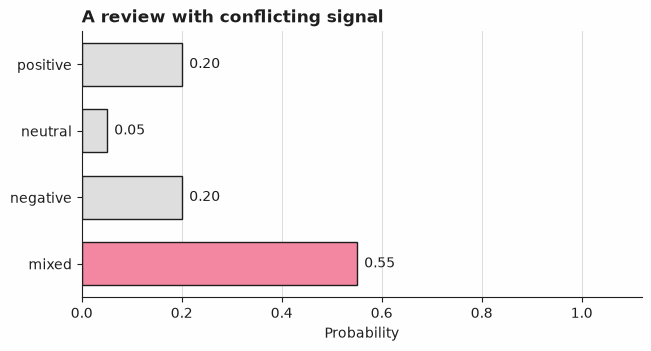

In [4]:
mixed_example = demo["d01-mixed"]
mixed_answer = decide(mixed_example)
show_answer(mixed_answer)
plot_answer_probabilities(mixed_answer, title="A review with conflicting signal")

The toaster review praises browning and criticizes the crumb tray in the same sentence. The stored answer puts `mixed` on top at 0.55, so `confidence` is only 0.40: `(0.55 - 0.25) / 0.75`. Confidence depends only on that top probability, not on how the rest is spread; here the remaining 0.45 happens to split evenly between `positive` and `negative`, 0.20 each, but it could just as well have piled onto one of them and the formula would report the same 0.40 either way. A low-confidence answer like this one says the top option did not clear much more than an even share, not that the review is unreadable.

In [5]:
short_example = demo["d02-short"]
short_answer = decide(short_example)
show_answer(short_answer)

Choice: neutral (confidence 0.13)
  neutral   0.35  #######
  positive  0.30  ######
  negative  0.20  ####
  mixed     0.15  ###
Provenance: synthetic


Two words ("Fine, I guess.") carry almost no signal either way, and the probabilities show it: the top option, `neutral`, barely leads `positive`. A short review like this one is a hard case on purpose; there is often not enough text for any classifier, human or model, to be confident.

In [6]:
sarcasm_example = next(e for e in examples if e.id == "v03-sarcasm")
sarcasm_answer = decide(sarcasm_example)
print(sarcasm_example.fields["text"])
show_answer(sarcasm_answer)

Great, it broke on the second use. Exactly what I was hoping for.
Choice: positive (confidence 0.44)
  positive  0.58  ############
  negative  0.28  ######
  neutral   0.07  #
  mixed     0.07  #
Provenance: synthetic


"Great, it broke on the second use. Exactly what I was hoping for." is sarcastic: every sentiment-bearing word ("great", "hoping for") is positive on its face, and the actual complaint ("it broke") is stated almost in passing. The stored answer calls it `positive`; this recipe's gold label is `negative`. The evaluation below counts this one as wrong, on purpose: a fixture set where every stored answer is right would not teach anything about where a `Choice` answer can be mistaken. Nothing here says *why* a real model would get this one wrong, because nothing here is a real model: the probabilities were written by hand for this fixture, not produced by Jev.

## Python's part

Jev supplies the judgment; what happens with it is code. `classify` in `helpers.py` accepts the chosen label as given when the answer's confidence is at or above a threshold, and sends it to an explicit `review` outcome otherwise, whatever the label is: every option here is one Python is willing to report, so confidence is the only thing the rule checks. `tests/test_helpers.py` checks the rule at the boundary, outside `0` to `1`, and for a low-confidence answer of every one of the four labels, so a rule that quietly exempted one label from the threshold would fail it.

The threshold itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest threshold whose answered subset is perfectly accurate on the 19 `validation` reviews, which is as much coverage as this fixture set allows without accepting a wrong answer *on validation*. Applying that frozen threshold to the three answers shown above, plus one clearly positive review for contrast, shows both outcomes the rule can produce.

In [7]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
val_correct = [a.choice == g for a, g in zip(val_answers, val_gold, strict=True)]
val_confidence = [a.confidence for a in val_answers]
threshold = select_confidence_threshold(val_correct, val_confidence, target_accuracy=1.0)
print(f"chosen threshold, frozen from here on: {threshold:.4f}{selection}{check}")

confident_example = next(e for e in val_examples if e.id == "v01-positive")
confident_answer = decide(confident_example)
for shown_example, shown_answer in (
    (mixed_example, mixed_answer),
    (short_example, short_answer),
    (sarcasm_example, sarcasm_answer),
    (confident_example, confident_answer),
):
    result = helpers.classify(shown_example.fields["review_id"], shown_answer, threshold)
    print(
        f"{result.review_id}: {shown_answer.choice} at confidence {shown_answer.confidence:.2f} "
        f"-> {result.outcome} ({result.reason})"
    )

chosen threshold, frozen from here on: 0.4933 (a selection step, not a reported result) (a pipeline check, not a Jev result)
R3001: mixed at confidence 0.40 -> review (confidence below the threshold)
R3002: neutral at confidence 0.13 -> review (confidence below the threshold)
R1003: positive at confidence 0.44 -> review (confidence below the threshold)
R1001: positive at confidence 0.87 -> accepted (confident)


## Evaluation

The threshold was chosen and frozen above, on `validation`. This section reports what the frozen rule does: `helpers.classify` is applied to every example in `validation` and in `test`, and the counts below come from what it actually returns, not from a separate reimplementation of the same condition. Alongside that, `jev_cookbook.evaluation` reports accuracy of the raw choice, a confusion matrix against the gold labels, per-class precision and recall with `mixed` discussed on its own, and the coverage, accuracy and risk the frozen threshold produces on `test`. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries a different label.

In [8]:
def report(chosen, decided, gold, threshold):
    """Apply classify to every answer and tally what it actually did."""
    results = [
        helpers.classify(e.fields["review_id"], a, threshold)
        for e, a in zip(chosen, decided, strict=True)
    ]
    accepted = [
        (a, g)
        for r, a, g in zip(results, decided, gold, strict=True)
        if r.outcome == helpers.ACCEPTED
    ]
    right = sum(a.choice == g for a, g in accepted)
    reasons = {}
    for r in results:
        if r.outcome == helpers.REVIEW:
            reasons[r.reason] = reasons.get(r.reason, 0) + 1
    return results, len(accepted), right, reasons


_, n_accepted, n_right, val_reasons = report(val_examples, val_answers, val_gold, threshold)
print(f"validation, {len(val_examples)} examples{selection}{check}")
print(f"accuracy of the choice: {accuracy(val_gold, val_answers):.4f}{selection}{check}")
print(
    f"accepted by the rule at this threshold: {n_accepted} of {len(val_examples)}{selection}{check}"
)
print(f"right among those accepted: {n_right} of {n_accepted}{selection}{check}")
print(f"review reasons: {val_reasons or 'none'}{selection}{check}")

validation, 19 examples (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy of the choice: 0.9474 (a selection step, not a reported result) (a pipeline check, not a Jev result)
accepted by the rule at this threshold: 13 of 19 (a selection step, not a reported result) (a pipeline check, not a Jev result)
right among those accepted: 13 of 13 (a selection step, not a reported result) (a pipeline check, not a Jev result)
review reasons: {'confidence below the threshold': 6} (a selection step, not a reported result) (a pipeline check, not a Jev result)


In [ ]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]

_, n_accepted_t, n_right_t, test_reasons = report(test_examples, test_answers, test_gold, threshold)
print(f"test, {len(test_examples)} examples, threshold {threshold:.4f} frozen{check}")
print(f"accuracy of the choice: {accuracy(test_gold, test_answers):.4f}{check}")
print(f"accepted by the rule: {n_accepted_t} of {len(test_examples)}{check}")
print(f"right among those accepted: {n_right_t} of {n_accepted_t}{check}")
print(f"review reasons: {test_reasons or 'none'}{check}")

matrix = confusion_matrix(
    test_gold, test_answers, labels=["positive", "neutral", "negative", "mixed"]
)
width = max(len(label) for label in matrix.labels)
# The header's leader ("predicted ->") and each row's leader ("gold <label>") are
# different fixed phrases; padding both to the same leader_width, derived from this
# same width, is what keeps the header's columns and every row's columns lined up,
# whatever width this recipe's own labels turn out to need.
leader_width = max(width + len("gold "), len("predicted ->"))
header = "  ".join(f"{label:>{width}s}" for label in matrix.labels)
print(f"test confusion matrix, gold rows by predicted columns{check}:")
print(f"  {'predicted ->':<{leader_width}s}  {header}{check}")
for gold_label, row in zip(matrix.labels, matrix.matrix.tolist(), strict=True):
    counts = "  ".join(f"{count:{width}d}" for count in row)
    leader = f"gold {gold_label:<{width}s}"
    print(f"  {leader:<{leader_width}s}  {counts}{check}")
plot_confusion_matrix(matrix, title=f"Test split, {len(test_examples)} examples{check}")

Every error on `test` lands in the `positive` column: the sarcastic review above, a `mixed` review whose complaint comes second ("The keyboard feels great to type on, but two keys stopped registering within a week."), and a short, lukewarm review ("Fine.") are all called `positive`, which also happens to be the first option in `OPTIONS`. That pattern cannot be read as a finding about Jev: every probability above was written by hand for this fixture set, which was not designed to test whether option order matters. It is worth naming anyway, because TypeSafe's notes on Jev 1.13 (S07) document a real failure mode that would produce exactly this shape: a `Choice` answer can lean toward whichever option comes first in the list it is given. The documented remedy is to reorder `OPTIONS` and check that the answer stays consistent, and "The questions" above says why that is not free here (it changes every stored replay key).

This reads the raw choice directly, before the confidence gate above removes anything, so it reports every answer `decide` returned, not only the ones `classify` accepted. For each class, `precision` is, of the `test` reviews the raw choice named that label, the fraction that were actually right, and `recall` is, of that label's real `test` reviews, the fraction the raw choice actually named; `f1` is their harmonic mean, a single number that is low whenever either one is, and `support` is how many `test` reviews actually carry that gold label, so a recall figure is only as meaningful as its support is large.

In [10]:
per_class = per_class_metrics(
    test_gold, test_answers, labels=["positive", "neutral", "negative", "mixed"]
)
for label, counts in per_class.items():
    print(
        f"{label:8s} precision {counts.precision:.3f}  recall {counts.recall:.3f}  "
        f"f1 {counts.f1:.3f}  support {counts.support}{check}"
    )

positive precision 0.625  recall 1.000  f1 0.769  support 5 (a pipeline check, not a Jev result)
neutral  precision 1.000  recall 0.800  f1 0.889  support 5 (a pipeline check, not a Jev result)
negative precision 1.000  recall 0.833  f1 0.909  support 6 (a pipeline check, not a Jev result)
mixed    precision 1.000  recall 0.667  f1 0.800  support 3 (a pipeline check, not a Jev result)


`mixed` on its own: it has the lowest recall of the four classes on `test` (2 of its 3 reviews, support 3; the third, the keyboard review above, is called `positive`) and perfect precision (nothing that is not `mixed` is ever called `mixed`). In this fixture set, the stored `mixed` answers only commit to `mixed` when both halves of a review are hard to miss, and the one the rule misses is the review whose complaint is the quieter half, a pattern in the hand-written probabilities, not a finding about how Jev actually resolves mixed signal. `positive` pays for the three `test` misses with the lowest precision of the four classes, 0.625, even though its own recall is perfect; every genuinely positive review is still called `positive`.

The `accepted`/`review` counts above come straight from `classify`; `evaluate_selective` reports the same split through `jev_cookbook.evaluation`'s own vocabulary. `coverage` is the fraction of all nineteen `test` reviews that clear the threshold and get a reported label; among those, `accuracy` is the fraction that are right, and `risk` is its complement, `1 - accuracy`, the fraction that are wrong despite having cleared the bar.

In [11]:
test_correct = [a.choice == g for a, g in zip(test_answers, test_gold, strict=True)]
test_confidence = [a.confidence for a in test_answers]
selective = evaluate_selective(test_correct, test_confidence, threshold)
print(
    f"answered: {selective.n_answered} of {selective.n_total} "
    f"(coverage {selective.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {selective.accuracy:.4f}{check}")
print(f"risk among those answered: {selective.risk:.4f}{check}")

answered: 13 of 19 (coverage 0.6842) (a pipeline check, not a Jev result)
accuracy among those answered: 0.9231 (a pipeline check, not a Jev result)
risk among those answered: 0.0769 (a pipeline check, not a Jev result)


At this threshold, two of `test`'s three errors, the sarcastic review and the lukewarm "Fine." review, fall below it and go to `review` instead of being reported as a result. The third, the keyboard review (`t16-mixed`), does not: its stored answer is wrong at confidence 0.60, comfortably above the 0.4933 frozen on `validation`, so the rule accepts it anyway. That is why `risk` above is 0.0769 and not 0: a threshold chosen to be perfectly accurate on `validation` is a guarantee about `validation`, not about `test` or about any review this recipe has not seen. The coverage side of the trade still holds here, six of the nineteen `test` reviews go to review, and four of those six are reviews the rule would have gotten right anyway, but the accuracy side does not, on purpose, so this recipe does not teach a threshold as a guarantee it is not.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 38 scored reviews (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, some of them wrong on purpose (including one wrong *and* confident, to show what a frozen threshold does not catch), so every number above describes this fixture set and not a model.

In [12]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard review to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `classify` sends it.
- Change the threshold's target in the evaluation cell (`target_accuracy=1.0` to something looser) and see how coverage and the review count trade off.
- Neighbouring recipes: [`02-refund-intent-detection`](../02-refund-intent-detection/) (a `Noul` question), and [`04-support-ticket-routing`](../04-support-ticket-routing/) and [`05-document-classification`](../05-document-classification/), which build on a `Choice` over a fixed option set like this one.